# Feature Selection: Embedded Method

## Daftar Isi
1. [Apa itu Feature Selection?](#1-apa-itu-feature-selection)
2. [Embedded Method](#2-embedded-method)
3. [Lasso Regression (L1 Regularization)](#3-lasso-regression-l1-regularization)
4. [Ridge Regression (L2 Regularization)](#4-ridge-regression-l2-regularization)
5. [Elastic Net Regression](#5-elastic-net-regression)
6. [Implementasi dengan Dataset Car Price Prediction](#6-implementasi-dengan-dataset-car-price-prediction)
7. [Perbandingan Ketiga Algoritma](#7-perbandingan-ketiga-algoritma)
8. [Kesimpulan](#8-kesimpulan)

---

## 1. Apa itu Feature Selection?

**Feature Selection** adalah proses memilih subset fitur (variabel input) yang paling relevan dari keseluruhan fitur yang tersedia dalam dataset. Tujuannya adalah untuk:

- Meningkatkan performa model prediksi
- Mengurangi kompleksitas model
- Menghindari *overfitting*
- Mempercepat waktu pelatihan
- Meningkatkan interpretabilitas model

### Tiga Kategori Feature Selection

| Kategori | Deskripsi | Contoh |
|----------|-----------|--------|
| **Filter Method** | Menyeleksi fitur berdasarkan statistik, independen dari model | Correlation, Chi-Square, ANOVA |
| **Wrapper Method** | Menggunakan model untuk mengevaluasi subset fitur | RFE, Forward Selection, Backward Elimination |
| **Embedded Method** | Seleksi fitur terintegrasi dalam proses pelatihan model | Lasso, Ridge, Elastic Net, Decision Tree |

---

## 2. Embedded Method

**Embedded Method** adalah pendekatan feature selection yang menggabungkan proses seleksi fitur **ke dalam proses pelatihan model** itu sendiri. Berbeda dengan Filter dan Wrapper, Embedded Method melakukan seleksi secara otomatis saat model sedang dioptimasi.

### Cara Kerja

Embedded Method bekerja dengan menambahkan **regularization term** (penalti) ke dalam fungsi loss model. Penalti ini memaksa model untuk "menghukum" koefisien fitur yang tidak penting, sehingga koefisien tersebut mengecil mendekati nol atau bahkan menjadi nol.

**Fungsi loss umum tanpa regularisasi:**

```
Loss = Σ(y_i - ŷ_i)²
```

**Fungsi loss dengan regularisasi:**

```
Loss = Σ(y_i - ŷ_i)² + Penalty(θ)
```

### Keunggulan Embedded Method

- **Efisien secara komputasi** — tidak perlu melatih model berkali-kali seperti Wrapper
- **Lebih akurat dari Filter** — mempertimbangkan interaksi antar fitur
- **Mengurangi overfitting** — secara bersamaan dengan seleksi fitur
- **Menghasilkan model yang sparse** (khusus L1) — banyak koefisien bernilai nol

---

## 3. Lasso Regression (L1 Regularization)

### Pengertian

**Lasso** (*Least Absolute Shrinkage and Selection Operator*) adalah teknik regresi yang menambahkan penalti berupa **jumlah nilai absolut koefisien** ke fungsi loss. Lasso diperkenalkan oleh Robert Tibshirani pada tahun 1996.

### Fungsi Objektif

```
Loss_Lasso = Σ(y_i - ŷ_i)² + λ × Σ|θ_j|
              \_____MSE_____/   \_L1 Penalty_/
```

- `λ` (lambda / alpha): Hyperparameter yang mengontrol kekuatan regularisasi
- `|θ_j|`: Nilai absolut koefisien ke-j

### Karakteristik Utama

**1. Sparse Solution (Feature Selection Otomatis)**
Lasso cenderung membuat banyak koefisien menjadi **tepat nol**. Hal ini terjadi karena sifat geometri penalti L1 yang membentuk diamond/berlian, sehingga solusi optimal sering jatuh tepat di sudut (sparse).

**2. Efek terhadap α (alpha)**

| Nilai α | Efek |
|---------|------|
| α = 0 | Sama dengan OLS (tidak ada regularisasi) |
| α kecil | Sedikit koefisien yang di-shrink ke nol |
| α besar | Banyak koefisien menjadi nol (model semakin sparse) |

**3. Keterbatasan**
- Jika ada fitur yang berkorelasi tinggi, Lasso cenderung memilih satu dan mengabaikan yang lain secara acak
- Tidak stabil jika jumlah fitur > jumlah sampel

### Kapan Menggunakan Lasso?

Gunakan Lasso ketika:
- Anda menduga hanya sedikit fitur yang benar-benar penting (*true sparsity*)
- Anda ingin melakukan feature selection otomatis
- Interpretabilitas model adalah prioritas

---

## 4. Ridge Regression (L2 Regularization)

### Pengertian

**Ridge Regression** (disebut juga *Tikhonov regularization*) menambahkan penalti berupa **jumlah kuadrat koefisien** ke fungsi loss. Ridge tidak melakukan feature selection secara eksplisit, melainkan men-*shrink* semua koefisien mendekati nol (tetapi tidak tepat nol).

### Fungsi Objektif

```
Loss_Ridge = Σ(y_i - ŷ_i)² + λ × Σθ_j²
              \_____MSE_____/   \__L2 Penalty__/
```

- `λ` (lambda / alpha): Hyperparameter yang mengontrol kekuatan regularisasi
- `θ_j²`: Kuadrat koefisien ke-j

### Karakteristik Utama

**1. Shrinkage tanpa Zeroing**
Ridge menyusutkan semua koefisien mendekati nol, tetapi **tidak pernah membuat koefisien menjadi tepat nol**. Ini karena sifat geometri penalti L2 yang berbentuk lingkaran/bola.

**2. Menangani Multikolinearitas**
Ridge sangat efektif saat ada fitur-fitur yang berkorelasi tinggi. Alih-alih memilih salah satu, Ridge mendistribusikan bobot secara merata di antara fitur-fitur tersebut.

**3. Efek terhadap α (alpha)**

| Nilai α | Efek |
|---------|------|
| α = 0 | Sama dengan OLS |
| α kecil | Koefisien sedikit di-shrink |
| α besar | Koefisien mendekati nol (tapi tidak pernah nol) |

### Kapan Menggunakan Ridge?

Gunakan Ridge ketika:
- Terdapat multikolinearitas antar fitur
- Semua fitur dianggap relevan dan ingin tetap dipertahankan
- Anda ingin stabilitas koefisien, bukan sparsity

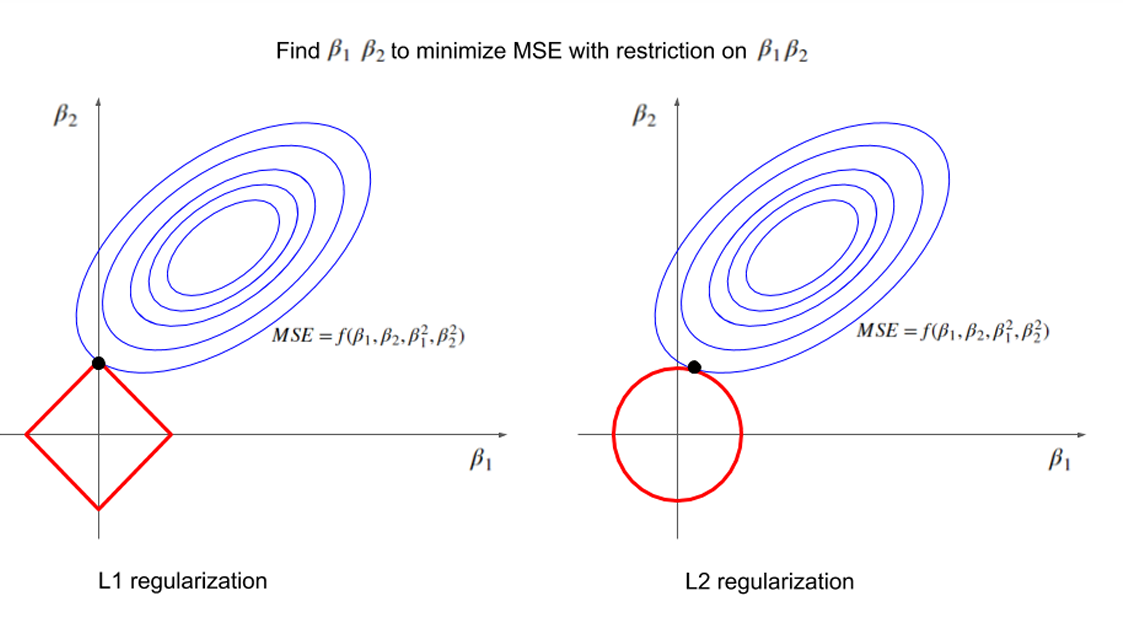

---

## 5. Elastic Net Regression

### Pengertian

**Elastic Net** adalah kombinasi dari Lasso (L1) dan Ridge (L2). Elastic Net diperkenalkan oleh Zou dan Hastie pada 2005 sebagai solusi atas kelemahan masing-masing metode.

### Fungsi Objektif

```
Loss_ElasticNet = Σ(y_i - ŷ_i)² + λ × [ρ × Σ|θ_j| + (1-ρ)/2 × Σθ_j²]
                  \_____MSE_____/    \______Elastic Net Penalty____/
```

- `λ` (alpha): Mengontrol kekuatan regularisasi keseluruhan
- `ρ` (l1_ratio / rho): Mengontrol proporsi L1 vs L2
  - `ρ = 1` → murni Lasso
  - `ρ = 0` → murni Ridge
  - `0 < ρ < 1` → campuran keduanya

### Karakteristik Utama

**1. Grouping Effect**
Ketika ada fitur yang berkorelasi tinggi, Elastic Net cenderung memilih atau mengeliminasi mereka **bersama-sama** (group selection), tidak seperti Lasso yang memilih secara acak.

**2. Menghasilkan Sparse Solution**
Seperti Lasso, Elastic Net dapat membuat koefisien menjadi tepat nol, sehingga tetap melakukan feature selection.

**3. Lebih Stabil dari Lasso**
Elastic Net lebih stabil daripada Lasso saat jumlah fitur melebihi jumlah sampel, karena efek Ridge-nya memberikan stabilitas numerik.

**4. Hyperparameter**

| Parameter | Deskripsi |
|-----------|-----------|
| `alpha` | Kekuatan regularisasi (sama seperti λ) |
| `l1_ratio` | Proporsi L1 (0 = Ridge murni, 1 = Lasso murni) |

### Kapan Menggunakan Elastic Net?

Gunakan Elastic Net ketika:
- Terdapat banyak fitur yang saling berkorelasi
- Anda ingin kelebihan keduanya: sparsity dari Lasso + stabilitas dari Ridge
- Jumlah fitur sangat besar (high-dimensional data)

---

## 6. Implementasi dengan Dataset Car Price Prediction

### Tentang Dataset
 
Dataset `AmesHousing.csv` berisi data harga rumah di kota Ames, Iowa, USA. Dataset ini sangat cocok untuk studi embedded feature selection karena memiliki **dimensionalitas tinggi** dengan banyak fitur yang saling berinteraksi. Secara keseluruhan dataset terdiri dari **2.930 baris** dan **82 kolom** (termasuk target).
 
| Kolom | Deskripsi | Tipe |
|-------|-----------|------|
| SalePrice | Harga jual rumah — **Target** | Numerik |
| Overall Qual | Penilaian kualitas keseluruhan (1–10) | Numerik |
| Gr Liv Area | Luas area hidup di atas tanah (sqft) | Numerik |
| Year Built | Tahun pembangunan | Numerik |
| Garage Cars | Kapasitas garasi (jumlah mobil) | Numerik |
| Garage Area | Luas garasi (sqft) | Numerik |
| Total Bsmt SF | Total luas basement (sqft) | Numerik |
| 1st Flr SF | Luas lantai 1 (sqft) | Numerik |
| Mas Vnr Area | Luas veneer batu bata (sqft) | Numerik |
| Exter Qual | Kualitas material eksterior | Kategorikal |
| Kitchen Qual | Kualitas dapur | Kategorikal |
| Bsmt Qual | Kualitas basement | Kategorikal |
| Neighborhood | Lokasi lingkungan di Ames | Kategorikal |
| MS SubClass | Tipe bangunan dan kelas zoning | Numerik |
| ... | *(79 fitur total setelah preprocessing)* | ... |
 
> Dataset ini memiliki **43 fitur kategorikal** dan **39 fitur numerik**, serta beberapa kolom dengan missing values yang perlu ditangani — menjadikannya benchmark ideal untuk membandingkan ketiga metode regularisasi.

### Preprocessing

In [22]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [23]:
df = pd.read_csv('AmesHousing.csv')
 
# Hapus kolom ID yang tidak informatif
df = df.drop(columns=['Order', 'PID'])
 
# Pisahkan target
y = df['SalePrice']
df = df.drop(columns=['SalePrice'])
 
# Tangani missing values:
# - Numerik  → isi dengan median
# - Kategorikal → isi dengan 'None' (artinya fitur tidak ada, misal: no pool)
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna('None')

In [ ]:
# Label Encoding untuk semua kolom kategorikal
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
 
feature_cols = df.columns.tolist()
X = df.values
 
# Standarisasi fitur 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
 
# Split data 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
 
print(f"Training set      : {X_train.shape[0]} sampel")
print(f"Testing set       : {X_test.shape[0]} sampel")
print(f"Jumlah fitur      : {len(feature_cols)}")
print(f"Fitur kategorikal : {len(cat_cols)}")

Training set      : 2344 sampel
Testing set       : 586 sampel
Jumlah fitur      : 79
Fitur kategorikal : 43


### Implementasi Lasso (L1)

In [44]:
# Inisialisasi dan latih model Lasso
lasso = Lasso(alpha=100)
lasso.fit(X_train, y_train)
 
# Prediksi
y_pred_lasso = lasso.predict(X_test)
 
# Evaluasi
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso   = r2_score(y_test, y_pred_lasso)
 
print("=" * 55)
print("EVALUASI MODEL LASSO (L1)")
print("=" * 55)
print(f"RMSE  : {rmse_lasso:,.2f}")
print(f"MAE   : {mae_lasso:,.2f}")
print(f"R²    : {r2_lasso:.4f}")

EVALUASI MODEL LASSO (L1)
RMSE  : 33,343.03
MAE   : 20,106.22
R²    : 0.8613


In [26]:
# Tampilkan koefisien
pd.set_option('display.max_rows', None)
coef_lasso = pd.Series(lasso.coef_, index=feature_cols)
print("\nTop 10 fitur berpengaruh (Lasso):")
coef = coef_lasso.reindex(coef_lasso.abs().sort_values(ascending=False).index)
print(coef)


Top 10 fitur berpengaruh (Lasso):
Gr Liv Area        26039.405108
Overall Qual       17335.002507
Year Built          7826.836576
Exter Qual         -6958.503167
Garage Cars         6163.823585
Mas Vnr Area        5556.916256
MS SubClass        -5210.950507
Kitchen Qual       -5155.558836
Overall Cond        4997.171306
Misc Val           -4975.554604
BsmtFin SF 1        4784.085400
Bsmt Exposure      -4286.017083
Screen Porch        3976.929087
Bsmt Qual          -3706.782252
Pool QC            -3625.548533
Lot Area            3578.513107
Sale Condition      3488.023994
Fireplaces          3420.006360
Exterior 1st       -3367.448094
Bsmt Full Bath      3016.187609
Mas Vnr Type        2812.302112
Functional          2584.770390
Pool Area          -2310.460367
Fireplace Qu       -2266.808779
Garage Type         2262.939082
Wood Deck SF        2229.032591
Bldg Type          -2183.953113
Garage Finish      -1973.489634
Roof Style          1968.836234
Yr Sold            -1840.603787
Kitch

In [27]:
zeroed = (coef_lasso.abs() < 0.01).sum()
print(f"\nFitur di-zeroed (|coef| < 0.01): {zeroed}/{len(feature_cols)}")
print("Fitur yang dieliminasi:", coef_lasso[coef_lasso.abs() < 0.01].index.tolist())


Fitur di-zeroed (|coef| < 0.01): 6/79
Fitur yang dieliminasi: ['Alley', 'BsmtFin Type 2', 'Bsmt Unf SF', 'Electrical', '2nd Flr SF', 'Paved Drive']


### Implementasi Ridge (L2)

In [28]:
# Inisialisasi dan latih model Ridge
ridge = Ridge(alpha=100)
ridge.fit(X_train, y_train)
 
# Prediksi
y_pred_ridge = ridge.predict(X_test)
 
# Evaluasi
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge   = r2_score(y_test, y_pred_ridge)
 
print("=" * 55)
print("EVALUASI MODEL RIDGE (L2)")
print("=" * 55)
print(f"RMSE  : {rmse_ridge:,.2f}")
print(f"MAE   : {mae_ridge:,.2f}")
print(f"R²    : {r2_ridge:.4f}")

EVALUASI MODEL RIDGE (L2)
RMSE  : 33,278.94
MAE   : 20,021.58
R²    : 0.8619


In [29]:
# Tampilkan koefisien
coef_ridge = pd.Series(ridge.coef_, index=feature_cols)
print("\nTop 10 fitur berpengaruh (Ridge):")
coef_r = coef_ridge.reindex(coef_ridge.abs().sort_values(ascending=False).index)
print(coef_r)


Top 10 fitur berpengaruh (Ridge):
Overall Qual       15805.974545
Gr Liv Area        13245.574179
2nd Flr SF          8362.188740
1st Flr SF          8009.759916
Exter Qual         -6966.681038
Year Built          6031.941987
Mas Vnr Area        5646.510893
Garage Cars         5415.856621
Kitchen Qual       -5327.474043
Misc Val           -4845.075172
Overall Cond        4728.659193
MS SubClass        -4439.979349
Bsmt Exposure      -4109.427729
Bsmt Qual          -4076.548881
Screen Porch        3970.597984
BsmtFin SF 1        3873.448671
Fireplaces          3850.587205
Pool QC            -3760.296428
Sale Condition      3468.410391
Lot Area            3457.498399
Total Bsmt SF       3439.621768
Exterior 1st       -3292.356179
Bsmt Full Bath      2933.393390
Functional          2668.026838
Mas Vnr Type        2660.356294
TotRms AbvGrd       2492.577448
Bldg Type          -2455.860126
Wood Deck SF        2324.342745
Fireplace Qu       -2302.989682
Kitchen AbvGr      -2222.186914
Pool 

In [30]:
zeroed = (coef_ridge.abs() < 0.01).sum()
print(f"\nFitur di-zeroed (|coef| < 0.01): {zeroed}/{len(feature_cols)}")


Fitur di-zeroed (|coef| < 0.01): 0/79


### Implementasi Elastic Net

In [ ]:
# Inisialisasi dan latih model Elastic Net
elastic_net = ElasticNet(alpha=10, l1_ratio=0.5, max_iter=10000)
elastic_net.fit(X_train, y_train)
 
# Prediksi
y_pred_en = elastic_net.predict(X_test)
 
# Evaluasi
rmse_en = np.sqrt(mean_squared_error(y_test, y_pred_en))
mae_en  = mean_absolute_error(y_test, y_pred_en)
r2_en   = r2_score(y_test, y_pred_en)
 
print("=" * 55)
print("EVALUASI MODEL ELASTIC NET")
print("=" * 55)
print(f"RMSE  : {rmse_en:,.2f}")
print(f"MAE   : {mae_en:,.2f}")
print(f"R²    : {r2_en:.4f}")

EVALUASI MODEL ELASTIC NET
RMSE  : 48,740.93
MAE   : 29,264.95
R²    : 0.7037


In [32]:
coef_en = pd.Series(elastic_net.coef_, index=feature_cols)
print("\nTop 10 fitur berpengaruh (Elastic Net):")
coef_e = coef_en.reindex(coef_en.abs().sort_values(ascending=False).index)
print(coef_e)



Top 10 fitur berpengaruh (Elastic Net):
Overall Qual       4631.010085
Gr Liv Area        4213.925877
Exter Qual        -3591.852108
Kitchen Qual      -3405.376398
1st Flr SF         3325.822001
Total Bsmt SF      3295.034513
Garage Area        3162.361898
Garage Cars        3157.220705
Bsmt Qual         -2832.492172
Fireplaces         2813.006307
TotRms AbvGrd      2678.489024
Full Bath          2645.441466
Mas Vnr Area       2627.721895
BsmtFin SF 1       2424.207366
Year Remod/Add     2401.805243
Year Built         2174.943963
Heating QC        -2039.411358
Garage Yr Blt      1979.018326
Garage Finish     -1975.566354
2nd Flr SF         1929.314400
Wood Deck SF       1727.959213
Bsmt Exposure     -1691.572724
Bsmt Full Bath     1637.762625
Lot Area           1576.030871
Foundation         1566.526619
Garage Type       -1500.299133
Half Bath          1446.845289
Lot Frontage       1443.176586
Lot Shape         -1419.761065
Roof Style         1394.623390
Open Porch SF      1349.86586

In [33]:
zeroed = (coef_en.abs() < 0.01).sum()
print(f"\nFitur di-zeroed (|coef| < 0.01): {zeroed}/{len(feature_cols)}")


Fitur di-zeroed (|coef| < 0.01): 1/79



 **Fitur yang dieliminasi Lasso (koefisien = 0):**
```
2nd Flr SF, Bsmt Unf SF, Paved Drive, Electrical, Alley, BsmtFin Type 2
```
Fitur-fitur ini dianggap tidak memberikan informasi tambahan yang signifikan setelah fitur-fitur lain telah dimasukkan, sehingga Lasso secara otomatis mengeksklusinya.
 
---
 
## 7. Perbandingan Ketiga Algoritma
 
### Perbandingan Performa
 
| Metrik | Lasso (L1) | Ridge (L2) | Elastic Net | Terbaik |
|--------|----------:|----------:|------------:|---------|
| **RMSE** | 33,343.03 | **33,278.94** | 48,740.93 | Ridge 🏆 |
| **MAE** | 20,106.22 | **20,021.58** | 29,264.95 | Ridge 🏆 |
| **R²** | 0.8613 | **0.8619** | 0.7037 | Ridge 🏆 |
| **Fitur di-zeroed** | **6/79** | 0/79 | 1/79 | Lasso (paling sparse) |
 
> Dengan dataset Ames Housing yang memiliki 79 fitur, perbedaan antar model menjadi jauh lebih jelas dibanding dataset dengan fitur sedikit. Lasso secara aktif mengeliminasi 6 fitur, sementara Ridge mempertahankan semua fitur dengan shrinkage seragam.
 
### Perbandingan Koefisien Fitur Kunci
 
| Fitur | Lasso | Ridge | Elastic Net | Catatan |
|-------|------:|------:|------------:|---------|
| Gr Liv Area | 26,039.41 | 13,245.57 | 4,213.93 | Lasso sangat dominan di fitur ini |
| Overall Qual | 17,335.00 | 15,805.97 | 4,631.01 | Konsisten di Lasso & Ridge |
| 2nd Flr SF | **0.00** | 8,362.19 | 1,929.31 | Dieliminasi Lasso, besar di Ridge |
| 1st Flr SF | 548.99 | 8,009.76 | 3,325.82 | Lasso men-shrink drastis |
| Overall Cond | 4,997.17 | 4,728.66 | 237.30 | Elastic Net paling konservatif |
| Misc Val | -4,975.55 | -4,845.08 | -629.47 | Elastic Net beda jauh |
| Alley | **0.00** | 161.33 | 271.54 | Dieliminasi Lasso, kecil di Ridge |
| Electrical | **0.00** | -105.83 | 834.66 | Elastic Net beda arah dari Ridge |
| Bsmt Unf SF | **0.00** | — | — | Hanya Lasso yang eliminasi |
 
 
### Analisis Perbedaan Koefisien
 
**Lasso vs Ridge — Perbedaan pada `2nd Flr SF` dan `1st Flr SF`:**
 
Ini adalah contoh klasik penanganan multikolinearitas. Kedua fitur (`1st Flr SF` dan `2nd Flr SF`) berkorelasi dengan `Gr Liv Area` (total luas hunian). Lasso memilih untuk memberikan hampir semua bobot ke `Gr Liv Area` dan men-shrink `1st Flr SF` + mengeliminasi `2nd Flr SF`. Ridge justru mendistribusikan bobot ke ketiganya secara lebih seimbang.
 
**Elastic Net — Lebih agresif men-shrink semua koefisien:**
 
Elastic Net dengan `alpha=10, l1_ratio=0.5` menghasilkan koefisien yang jauh lebih kecil dari Lasso dan Ridge. Ini karena penalti gabungan L1+L2 memberikan *double regularization*, sehingga model lebih konservatif. Pada pengaturan ini R²-nya (0.7037) lebih rendah dari keduanya, yang bisa diperbaiki dengan tuning `alpha` lebih kecil.
 
**Implikasi Feature Selection:**
 
Pada dataset dengan 79 fitur seperti Ames Housing, kemampuan Lasso mengeliminasi 6 fitur tidak relevan (`2nd Flr SF`, `Alley`, `Electrical`, dll.) sangat berguna untuk menyederhanakan model akhir tanpa kehilangan performa yang signifikan (R² hanya turun 0.0006 dibanding Ridge).
 
---
 
## 8. Kesimpulan
 
### Ringkasan Temuan
 
Dari implementasi ketiga metode embedded feature selection pada dataset **Ames Housing** dengan **79 fitur** dan **2.930 sampel**:
 
**1. Performa Prediksi**
 
Ridge menghasilkan performa terbaik (RMSE = 33,278 | R² = 0.8619), diikuti Lasso (RMSE = 33,343 | R² = 0.8613) dengan selisih sangat kecil. Elastic Net pada konfigurasi yang digunakan menghasilkan performa lebih rendah (R² = 0.7037) karena double-regularization yang terlalu agresif — bisa diperbaiki dengan menurunkan nilai `alpha`.
 
Nilai R² ≈ 0.86 menunjukkan ketiga model cukup baik menangkap varians harga rumah, mengonfirmasi bahwa dataset Ames Housing memiliki struktur linear yang kuat.
 
**2. Feature Selection: Lasso Unggul**
 
Lasso secara otomatis mengeliminasi 6 dari 79 fitur, yaitu `2nd Flr SF`, `Bsmt Unf SF`, `Paved Drive`, `Electrical`, `Alley`, dan `BsmtFin Type 2`. Keenam fitur ini memiliki pengaruh redundan atau sangat kecil terhadap harga — informasinya sudah tercakup oleh fitur lain dalam model.
 
**3. Fitur Paling Penting (konsisten di ketiga model)**
 
| Ranking | Fitur | Pengaruh |
|---------|-------|---------|
| 1 | **Gr Liv Area** | Luas hunian — paling dominan di Lasso |
| 2 | **Overall Qual** | Kualitas keseluruhan — paling konsisten |
| 3 | **Year Built** | Tahun pembangunan — rumah baru lebih mahal |
| 4 | **Garage Cars** | Kapasitas garasi |
| 5 | **Mas Vnr Area** | Luas veneer bata — nilai estetika |
 
**4. Rekomendasi Penggunaan**
 
| Situasi | Rekomendasi |
|---------|-------------|
| Ingin feature selection otomatis | **Lasso** |
| Ada banyak fitur berkorelasi tinggi (seperti area measurements) | **Ridge** atau **Elastic Net** |
| Dataset berdimensi sangat tinggi | **Elastic Net** |
| Butuh interpretabilitas dan model simpel | **Lasso** |
| Tidak yakin mana yang terbaik | **Elastic Net** (paling fleksibel) |
 
### Perbedaan Kunci
 
```
Lasso      → Eliminasi fitur (sparse), baik untuk interpretasi
Ridge      → Shrinkage semua fitur, baik untuk multikolinearitas
ElasticNet → Gabungan keduanya, fleksibel dan robust
```
 
Ketiga metode ini merupakan fondasi penting dalam machine learning modern. Pemilihan metode yang tepat bergantung pada karakteristik data dan tujuan analisis. Dataset Ames Housing dengan 79 fitur berhasil menunjukkan perbedaan karakter masing-masing metode secara lebih nyata dibanding dataset berdimensi rendah.